Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

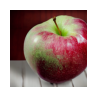

In [2]:
import sys
sys.path.append('../')
from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from diffusers.utils import load_image
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from causal_modules import Causal_SCM_v3

def save_images_grid(images_list, grid_size, save_path=None):
    """
    Save a list of lists of images in a grid format.

    Parameters:
    - images_list: List of lists containing numpy images (4x4).
    - grid_size: tuple (grid_rows, grid_cols) for arranging images in the grid.
    - save_path: file path where the grid image will be saved.
    """
    # Flatten the list of lists into a single list of images

    images = [np.asarray(img) for sublist in images_list for img in sublist]

    # Determine the dimensions of the first image to set up the grid
    H, W, C = images[0].shape
    grid_rows, grid_cols = grid_size

    # Check if the grid can fit all images
    assert grid_rows * grid_cols >= len(images), "Grid size is too small for the number of images"

    # Create an empty array for the grid image
    grid_image = np.zeros((grid_rows * H, grid_cols * W, C), dtype=images[0].dtype)

    # Fill the grid with images
    for idx, img in enumerate(images):
        row = idx // grid_cols
        col = idx % grid_cols
        grid_image[row * H:(row + 1) * H, col * W:(col + 1) * W, :] = img

    # Plot and save the grid image
    plt.figure(figsize=(grid_cols, grid_rows))
    plt.imshow(grid_image)
    plt.axis('off')  # Turn off axis labels
    # plt.savefig(save_path)
    # plt.close()


#
# prompt = "orange @ and red * and black & and black !"
prompt = "a apple"
generator = torch.manual_seed(0)
base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/f03de327dd89b501a01da37fc5240cf4fdba85a1"

controlnet_path = "../logs/2024-10-25T08-56-05-mcpl-all_controlv2_initial_mcpl/controlnet-steps-10000.safetensors/"
mcpl_embedding_path = "../logs/2024-10-25T08-56-05-mcpl-all_controlv2_initial_mcpl/learned_embeds-steps-10000.safetensors"

from diffusers import DDIMScheduler
without_control_pipe = StableDiffusionPipeline.from_pretrained(base_model_path,torch_dtype=torch.float32).to("cuda")
without_control_pipe.scheduler = DDIMScheduler.from_config(
    without_control_pipe.scheduler.config
)
without_control_pipe.safety_checker = None
without_control_pipe.requires_safety_checker = False
without_control_pipe.load_mcpl_inversion(mcpl_embedding_path)
without_control_images = without_control_pipe(prompt, generator=generator,num_inference_steps=50, guidance_scale=3,num_images_per_prompt=1,height=512,width=512).images[0]
without_control_images

#save_images_grid([[control_image,without_control_images,recons_image]],(1,3),save_path)
save_images_grid([[without_control_images]],(1,1))
